# Parse the Finite Width FEM Single dataset

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


In [2]:
def parse_file_header(file_header):
    # Regex pattern to extract the numbers
    pattern = r"Height\s*=\s*([\d\.]+)\*Width,\s*Thickness=\s*([\d\.]+),\s*Hole radius:\s*([\d\.]+)"

    match = re.search(pattern, file_header)
    if match:
        height_factor = float(match.group(1))
        thickness = float(match.group(2))
        radius = float(match.group(3))
        # print("Height factor:", height_factor)
        # print("Thickness:", thickness)
        # print("Hole radius:", radius)
        return height_factor, thickness, radius
    else:
        # print("Pattern not found.")
        return None, None, None


def parse_block_header(block_header):
    pattern = r"W/R\s*=\s*([\d\.]+),\s*Crack number:\s*(\d+)"

    match = re.search(pattern, block_header)
    if match:
        w_over_r = float(match.group(1))
        crack_number = int(match.group(2))
        # print("W/R:", w_over_r)
        # print("Crack number:", crack_number)
        return w_over_r, crack_number
    else:
        # print("Pattern not found.")
        return None, None

## Data Import as f(phi)

In [ ]:
# Create container to store total dataset
all_data = []
all_data_blocks = []


folder = "Finite Width FEM Single/"
for filename in os.listdir(folder):
    if filename.endswith(".DAT"):
        filepath = os.path.join(folder, filename)
        with open(filepath, "r") as f:
            lines = f.readlines()

            # Parse the values from the file header
            file_header = lines[0]
            main_header_misc = lines[1:5]
            height_factor, thickness, radius = parse_file_header(file_header)
            file_params_list = [height_factor, thickness, radius]

            # Iterate through all of the data blocks
            block_start_idx = 5
            while block_start_idx < len(lines):
                block_header = lines[block_start_idx]
                block_params_header = lines[block_start_idx + 1].strip().split()
                block_params = lines[block_start_idx + 2].strip().split()
                data_header = lines[block_start_idx + 3].strip().split()

                # Parse the values from the data block's header and parameter lines
                w_over_r, crack_number = parse_block_header(block_header)
                block_params_dict = {}
                for i in range(len(block_params_header)):
                    block_params_dict[block_params_header[i]] = block_params[i]
                block_params_list = [w_over_r, crack_number,
                                     block_params_dict["ndom"], block_params_dict["a/c"], block_params_dict["a/t"],
                                     block_params_dict["r/t"], block_params_dict["b/t"], block_params_dict["c"]]

                # Extract/store the data line-by-line until the next block begins (indicated by line starting with "Results")
                data = []
                block_data = {"params": [], "phi": [], "K-tension": [], "K-bending": [], "K-bearing": []}
                data_line_idx = block_start_idx + 4
                data_line = lines[data_line_idx].strip().split()
                while data_line[0] != "Results":
                    data.append(data_line)
                    data_line_idx += 1
                    data_line_dict = {}
                    for i in range(len(data_line)):
                        data_line_dict[data_header[i]] = data_line[i]

                    # Store the single data point in the full dataset container
                    crackpoint_data_list = [data_line_dict["phi"], data_line_dict["K-tension"], data_line_dict["K-bending"], data_line_dict["K-bearing"]]
                    complete_crackpoint_data_list = file_params_list + block_params_list + crackpoint_data_list
                    all_data.append(complete_crackpoint_data_list)
            
                    block_data["phi"].append(data_line_dict["phi"])
                    block_data["K-tension"].append(data_line_dict["K-tension"])
                    block_data["K-bending"].append(data_line_dict["K-bending"])
                    block_data["K-bearing"].append(data_line_dict["K-bearing"])


                    # Parse the next data line, unless it's the end of the file
                    try:
                        data_line = lines[data_line_idx].strip().split()
                    except IndexError as e:
                        print(f"File {filename}: Assuming end of file, {e} found")
                        break
                block_data["params"] = file_params_list + block_params_list

                all_data_blocks.append(block_data)
                block_start_idx = data_line_idx
                # break
    # break

print(len(all_data))
print(len(all_data_blocks))


In [ ]:
# Initialize lists to hold the data for each block
block_params_dataset = []
block_phi_dataset = []
block_Ktension_dataset = []
block_Kbending_dataset = []
block_Kbearing_dataset = []

for block in all_data_blocks:
    block_params_dataset.append(block["params"])
    block_phi_dataset.append(block["phi"])
    block_Ktension_dataset.append(block["K-tension"])
    block_Kbending_dataset.append(block["K-bending"])
    block_Kbearing_dataset.append(block["K-bearing"])

# Get the maximum data length across all blocks
block_lengths = []
for i in range(len(block_phi_dataset)):
    block_lengths.append(len(block_phi_dataset[i]))
max_block_length = max(block_lengths)

# Pad the lists up to the max length with NaNs
for i in range(len(block_phi_dataset)):
    while len(block_phi_dataset[i]) < max_block_length:
        block_phi_dataset[i].append(np.nan)
        block_Ktension_dataset[i].append(np.nan)
        block_Kbending_dataset[i].append(np.nan)
        block_Kbearing_dataset[i].append(np.nan)

# Convert to numpy arrays
# print(block_params_dataset)
block_params_dataset = np.array(block_params_dataset, dtype=np.float32)
block_phi_dataset = np.array(block_phi_dataset, dtype=np.float32)
block_Ktension_dataset = np.array(block_Ktension_dataset, dtype=np.float32)
block_Kbending_dataset = np.array(block_Kbending_dataset, dtype=np.float32)
block_Kbearing_dataset = np.array(block_Kbearing_dataset, dtype=np.float32)

# Save the numpy arrays
np.savez_compressed('formatted_block_data.npz',
                    block_params_dataset=block_params_dataset,
                    block_phi_dataset=block_phi_dataset,
                    block_Ktension_dataset=block_Ktension_dataset,
                    block_Kbending_dataset=block_Kbending_dataset,
                    block_Kbearing_dataset=block_Kbearing_dataset)

In [3]:
# Load in the saved block data
loaded_data = np.load('full_datasets/formatted_block_data.npz')
block_params_dataset = loaded_data['block_params_dataset']
block_phi_dataset = loaded_data['block_phi_dataset']
block_Ktension_dataset = loaded_data['block_Ktension_dataset']
block_Kbending_dataset = loaded_data['block_Kbending_dataset']
block_Kbearing_dataset = loaded_data['block_Kbearing_dataset']

num_phis = 0
for i in range(len(block_phi_dataset)):
    num_phis += len(block_phi_dataset[i])
print(f"Number of Solution points: {num_phis}")

Number of Solution points: 20272780


In [4]:
# Define full ML dataset indices for easier readability and slicing
height_factor_idx = 0  # Remove, variance=0
thickness_idx = 1
radius_idx = 2  # Remove, variance=0
w_over_r_idx = 3
crack_number_idx = 4
ndom_idx = 5
a_over_c_idx = 6
a_over_t_idx = 7
R_over_t_idx = 8
b_over_t_idx = 9  # Remove, variance=0
c_idx = 10
Ktension_c_idx = 11
Kbending_c_idx = 12
Kbearing_c_idx = 13
Ktension_a_idx = 14
Kbending_a_idx = 15
Kbearing_a_idx = 16

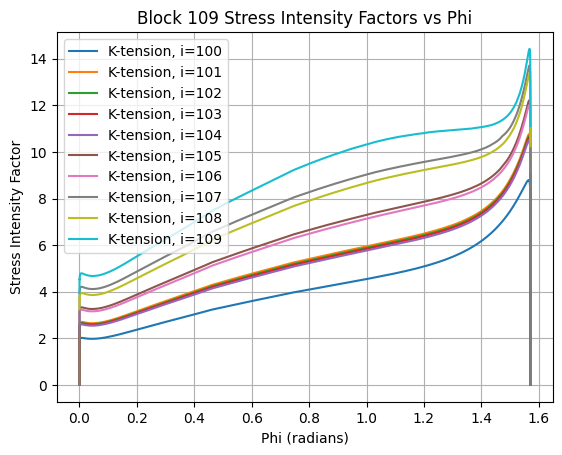

In [5]:

# Plots Ktension vs phi for block i
plt.figure()

for i in range(100, 110):
    plt.plot(block_phi_dataset[i], block_Ktension_dataset[i], label='K-tension, i='+str(i))
    # plt.plot(block_phi_dataset[i], block_Kbending_dataset[i], label='K-bending, i='+str(i))
    # plt.plot(block_phi_dataset[i], block_Kbearing_dataset[i], label='K-bearing, i='+str(i))

plt.xlabel('Phi (radians)')
plt.ylabel('Stress Intensity Factor')
plt.title(f'Block {i} Stress Intensity Factors vs Phi')
plt.legend()
plt.grid()
plt.show()


In [6]:
# Iterate through the data blocks
for i in range(len(block_phi_dataset)):
    # print(f"Analyzing Block {i}")
    max_angle = np.nanmax(block_phi_dataset[i])
    if max_angle > np.radians(91):
        print(max_angle)
    
    # Get all of the phi indices where phi is less than 5% of max phi angle
    phi_threshold = 0.05 * max_angle
    phi_indices = np.where(block_phi_dataset[i] < phi_threshold)[0]

In [7]:
# SIMPLIFIED TURNDOWN DETECTION - BEST SLOPE PATTERN
def find_turndown(values, indices, tolerance=1e-8, validation_window=3, reverse_order=False):
    """
    Simplified turndown detection that selects the peak with the most positive left slopes
    and negative right slopes within the validation window.
    
    Parameters:
    - values: array of values to search in
    - indices: indices to search within
    - tolerance: minimum slope magnitude to consider significant
    - validation_window: number of points to check on each side for pattern validation
    - reverse_order: whether to search from largest to smallest index
    
    Returns:
    - (index, value, found) tuple
    """
    
    if reverse_order:
        indices = indices[::-1]
    
    candidates = []
    
    # # Ensure we have enough points for validation window on both sides
    # if len(indices) < 2 * validation_window + 1:
    #     # Not enough points for proper validation, fall back to edge value
    #     furthest_idx = indices[-1]
    #     furthest_val = values[furthest_idx]
    #     return furthest_idx, furthest_val, False
    
    # Start and end iterations based on validation_window to ensure we can always collect enough slopes
    for i in range (1, len(indices) - 2):
    # for i in range(validation_window, len(indices) - validation_window):
        current_idx = indices[i]
        current_val = values[current_idx]
        
        if np.isnan(current_val):
            continue
        
        # Collect left slopes - start from i-1 and go back up to validation_window points
        left_slopes = []
        j = i
        while j >= 0 and j > 0 and len(left_slopes) < validation_window:
            # Calculate slope between consecutive points: (y2 - y1) 
            right_val = abs(values[indices[j]])
            left_val = abs(values[indices[j-1]])
            slope = right_val - left_val
            if abs(slope) > tolerance:
                left_slopes.append(slope)
            j -= 1
        
        # Collect right slopes - start from i+1 and go forward up to validation_window points
        right_slopes = []
        j = i
        while j < len(indices) and j < len(indices) - 1 and len(right_slopes) < validation_window:
            # Calculate slope between consecutive points: (y2 - y1)
            left_val = abs(values[indices[j]])
            right_val = abs(values[indices[j+1]])
            slope = right_val - left_val
            if abs(slope) > tolerance:
                right_slopes.append(slope)
            j += 1
        
        # Count positive left slopes and negative right slopes
        left_positive_count = sum(1 for s in left_slopes if s > 0)
        right_negative_count = sum(1 for s in right_slopes if s < 0)

        # print(f"  Found {len(candidates)} candidates with turndown patterns:")
        # print(f"index: {i}, val {current_val}, left_slopes {left_slopes}, right slopes {right_slopes}")
        
        # Proceed if there is at least one positive left slope and one negative right slope
        if left_positive_count > 0 and right_negative_count > 0:
            # Calculate the "turndown strength" as the total count of supporting slopes
            turndown_strength = left_positive_count + right_negative_count
            
            # Store the TRUE signed value from original data
            true_signed_value = values[current_idx]
            
            # Store candidate: (index, value, turndown_strength, left_pos, right_neg, abs_val)
            candidates.append((current_idx, i, true_signed_value, turndown_strength, 
                            left_positive_count, right_negative_count, len(left_slopes), len(right_slopes), current_val))
    
    
    # for i, (rel_idx, abs_idx, val, strength, left_pos, right_neg, left_total, right_total, val) in enumerate(candidates[:]):
    #     print(f"    {i+1}: Index {abs_idx}, Value {val:.6f}, Strength {strength}")
    #     print(f"        Left: {left_pos}/{left_total} positive, Right: {right_neg}/{right_total} negative")


    # If we found candidates, return the one with the highest turndown strength
    if candidates:
        # Sort by turndown strength (left_positive + right_negative), then by absolute value as tiebreaker
        best_candidate = max(candidates, key=lambda x: (x[2], x[5]))
        return best_candidate[0], best_candidate[2], True
    
    # Fallback to edge value if no turndown found
    else:
        furthest_idx = indices[-1]
        furthest_val = values[furthest_idx]

        # For confirmation, check if furthest value is absolute max
        if abs(furthest_val) < max(abs(values[indices])):
            print("Warning: Fallback furthest value is not absolute maximum in provided indices.")

        return furthest_idx, furthest_val, False

In [13]:
num_no_Ktension_c_vertex = []
num_no_Kbending_c_vertex = []
num_no_Kbearing_c_vertex = []
num_no_Ktension_a_vertex = []
num_no_Kbending_a_vertex = []
num_no_Kbearing_a_vertex = []

Ktension_c_vertex_indices = []
Ktension_c_vertex_values = []
Kbending_c_vertex_indices = []
Kbending_c_vertex_values = []
Kbearing_c_vertex_indices = []
Kbearing_c_vertex_values = []
Ktension_a_vertex_indices = []
Ktension_a_vertex_values = []
Kbending_a_vertex_indices = []
Kbending_a_vertex_values = []
Kbearing_a_vertex_indices = []
Kbearing_a_vertex_values = []

# Iterate through the data blocks
for i in tqdm(range(len(block_phi_dataset[:1000]))):
    # print(f"Analyzing Block {i}")
    max_angle = np.nanmax(block_phi_dataset[i])

    # If the max phi is over 90.1 degrees, print the iteration and angle
    if max_angle > np.radians(90.1):
        print(f"Analyzing Block {i}: Max angle exceeded: {max_angle}")
        break

    # ------------ Perform c-vertex extractions -------------
    # Extract the indices where phi is less than c_vertex_phi_threshold degrees (in radians)
    c_vertex_phi_threshold = 0.05 * max_angle
    indices = np.where(block_phi_dataset[i] < c_vertex_phi_threshold)[0]

    # Find the a turn-down point in the Ktension values by comparing discrete slopes
    vertex_idx, vertex_value, vertex_found = find_turndown(block_Ktension_dataset[i], indices, reverse_order=False)
    Ktension_c_vertex_indices.append(vertex_idx)
    Ktension_c_vertex_values.append(vertex_value)
    if not vertex_found:
        num_no_Ktension_c_vertex.append(i)

   # Find the a turn-down point in the Kbending values by comparing discrete slopes
    vertex_idx, vertex_value, vertex_found = find_turndown(block_Kbending_dataset[i], indices, reverse_order=False)
    Kbending_c_vertex_indices.append(vertex_idx)
    Kbending_c_vertex_values.append(vertex_value)
    if not vertex_found:
        num_no_Kbending_c_vertex.append(i)

    # Find the a turn-down point in the Kbearing values by comparing discrete slopes
    vertex_idx, vertex_value, vertex_found = find_turndown(block_Kbearing_dataset[i], indices, reverse_order=False)
    Kbearing_c_vertex_indices.append(vertex_idx)
    Kbearing_c_vertex_values.append(vertex_value)
    if not vertex_found:
        num_no_Kbearing_c_vertex.append(i)


    # ---------- Perform a-vertex extractions --------------
    # Extract the indices where phi is within 5% of the max phi angle
    a_vertex_phi_threshold = 0.95 * max_angle
    indices = np.where(block_phi_dataset[i] > a_vertex_phi_threshold)[0]

    # Find the a turn-down point in the Ktension values by comparing discrete slopes
    vertex_idx, vertex_value, vertex_found = find_turndown(block_Ktension_dataset[i], indices, reverse_order=True)
    Ktension_a_vertex_indices.append(vertex_idx)
    Ktension_a_vertex_values.append(vertex_value)
    if not vertex_found:
        num_no_Ktension_a_vertex.append(i)

    # Find the a turn-down point in the Kbending values by comparing discrete slopes
    vertex_idx, vertex_value, vertex_found = find_turndown(block_Kbending_dataset[i], indices, reverse_order=True)
    Kbending_a_vertex_indices.append(vertex_idx)
    Kbending_a_vertex_values.append(vertex_value)
    if not vertex_found:
        num_no_Kbending_a_vertex.append(i)

    # Find the a turn-down point in the Kbearing values by comparing discrete slopes
    vertex_idx, vertex_value, vertex_found = find_turndown(block_Kbearing_dataset[i], indices, reverse_order=True)
    Kbearing_a_vertex_indices.append(vertex_idx)
    Kbearing_a_vertex_values.append(vertex_value)
    if not vertex_found:
        num_no_Kbearing_a_vertex.append(i)

        
print(f"Total blocks with no Ktension c-vertex found: {len(num_no_Ktension_c_vertex)}")
print(f"Total blocks with no Kbending c-vertex found: {len(num_no_Kbending_c_vertex)}")
print(f"Total blocks with no Kbearing c-vertex found: {len(num_no_Kbearing_c_vertex)}")
print(f"Total blocks with no Ktension a-vertex found: {len(num_no_Ktension_a_vertex)}")
print(f"Total blocks with no Kbending a-vertex found: {len(num_no_Kbending_a_vertex)}")
print(f"Total blocks with no Kbearing a-vertex found: {len(num_no_Kbearing_a_vertex)}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Total blocks with no Ktension c-vertex found: 9
Total blocks with no Kbending c-vertex found: 0
Total blocks with no Kbearing c-vertex found: 114
Total blocks with no Ktension a-vertex found: 0
Total blocks with no Kbending a-vertex found: 61
Total blocks with no Kbearing a-vertex found: 0


In [14]:
print(len(Ktension_c_vertex_values))
print(len(Kbending_c_vertex_values))
print(len(Kbearing_c_vertex_values))
print(len(Ktension_a_vertex_values))
print(len(Kbending_a_vertex_values))
print(len(Kbearing_a_vertex_values))

print(num_no_Kbending_c_vertex)

# 


1000
1000
1000
1000
1000
1000
[]


w_over_r: 8.0
a_over_c: 0.11100000143051147
a_over_t: 0.10000000149011612
r_over_t: 0.4000000059604645
Recommended K-bearing c-vertex for block 31: Index 24, Value 1.0789999961853027, Found: True


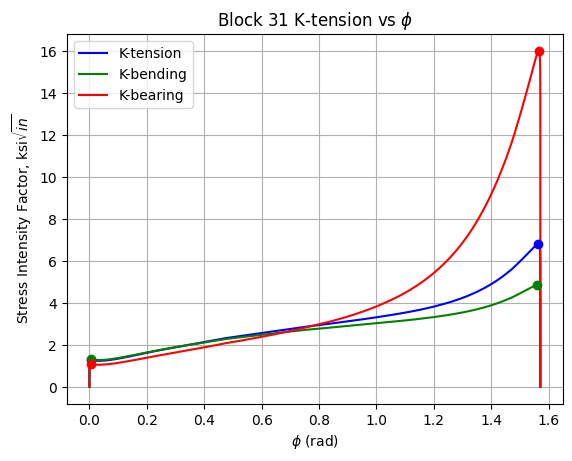

w_over_r: 250.0
a_over_c: 0.11100000143051147
a_over_t: 0.10000000149011612
r_over_t: 0.4000000059604645
Recommended K-bearing c-vertex for block 35: Index 25, Value 12.119999885559082, Found: True


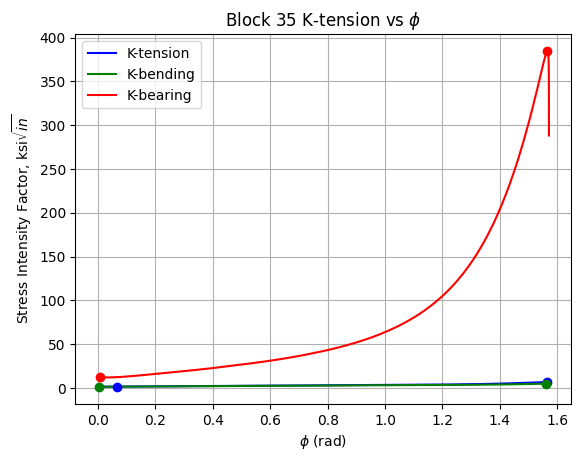

w_over_r: 4.0
a_over_c: 0.11100000143051147
a_over_t: 0.10000000149011612
r_over_t: 0.4000000059604645
Recommended K-bearing c-vertex for block 25: Index 25, Value 0.9797000288963318, Found: True


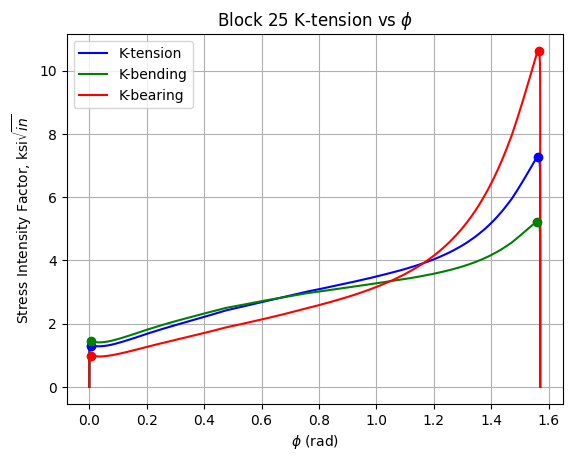

w_over_r: 6.400000095367432
a_over_c: 0.125
a_over_t: 0.10000000149011612
r_over_t: 0.4000000059604645
Recommended K-bearing c-vertex for block 57: Index 25, Value 1.1490000486373901, Found: True


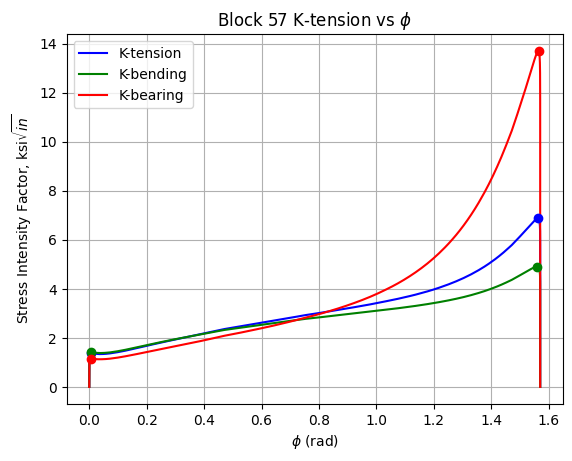

w_over_r: 12.0
a_over_c: 0.11100000143051147
a_over_t: 0.30000001192092896
r_over_t: 0.4000000059604645
Recommended K-bearing c-vertex for block 42: Index 24, Value 1.684000015258789, Found: True


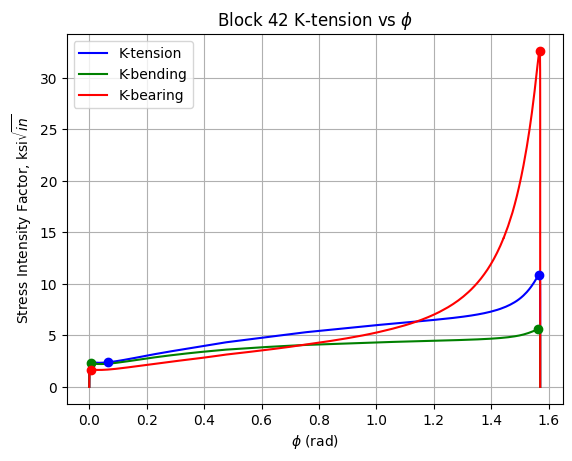

w_over_r: 15.0
a_over_c: 0.10000000149011612
a_over_t: 0.30000001192092896
r_over_t: 0.4000000059604645
Recommended K-bearing c-vertex for block 16: Index 23, Value 1.5740000009536743, Found: True


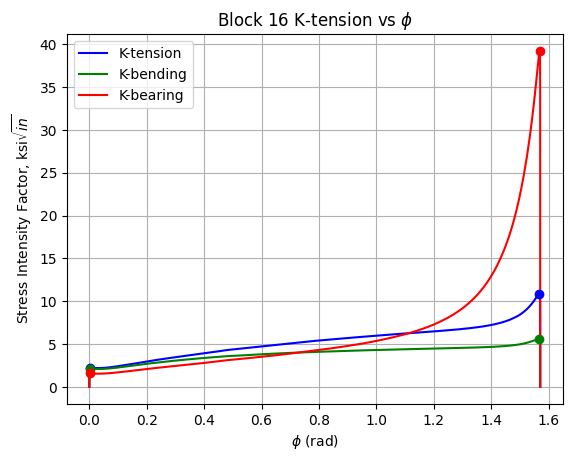

w_over_r: 250.0
a_over_c: 0.11100000143051147
a_over_t: 0.20000000298023224
r_over_t: 0.4000000059604645
Recommended K-bearing c-vertex for block 40: Index 24, Value 8.756999969482422, Found: True


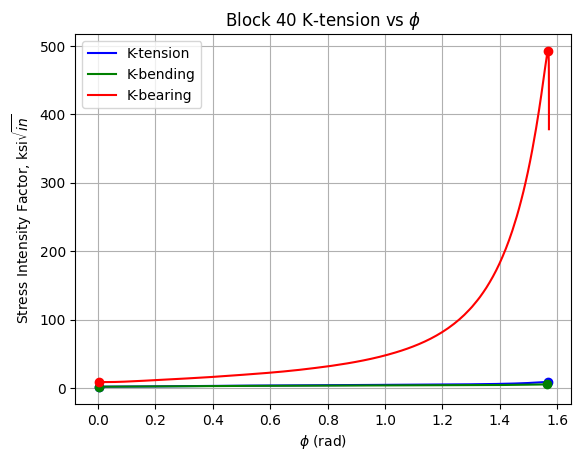

w_over_r: 250.0
a_over_c: 0.11100000143051147
a_over_t: 0.30000001192092896
r_over_t: 0.4000000059604645
Recommended K-bearing c-vertex for block 44: Index 24, Value 8.347000122070312, Found: True


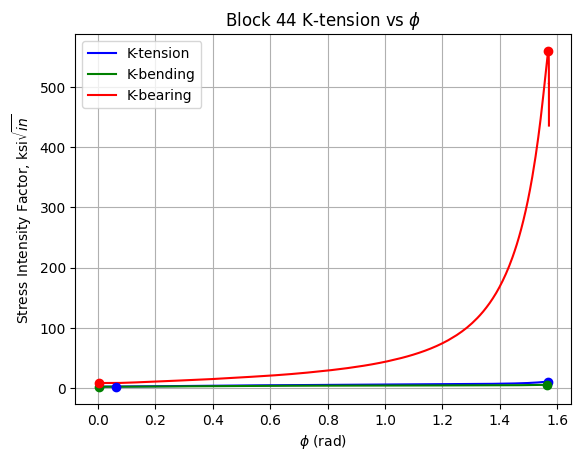

w_over_r: 250.0
a_over_c: 0.10000000149011612
a_over_t: 0.949999988079071
r_over_t: 0.4000000059604645
Recommended K-bearing c-vertex for block 24: Index 23, Value 16.530000686645508, Found: True


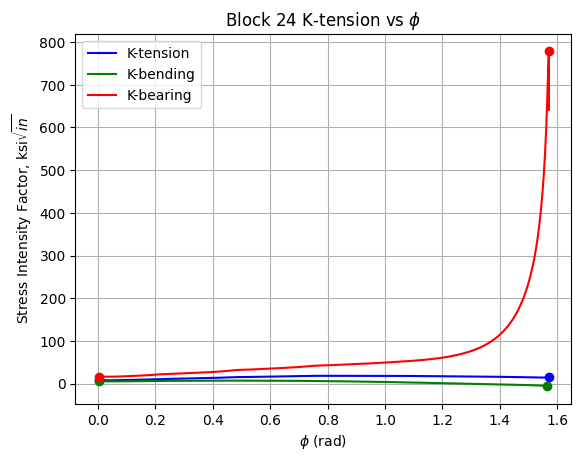

w_over_r: 8.0
a_over_c: 0.125
a_over_t: 0.10000000149011612
r_over_t: 0.4000000059604645
Recommended K-bearing c-vertex for block 59: Index 26, Value 1.2120000123977661, Found: True


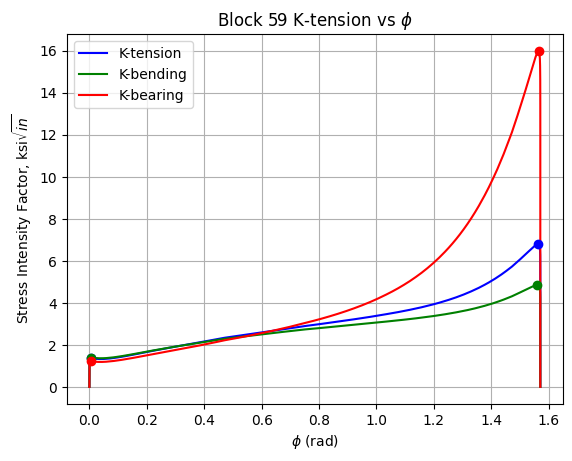

In [17]:
# for i in [146]:
dataset = num_no_Kbending_a_vertex
# dataset = np.arange(len(block_phi_dataset))
dataset_size = len(dataset)
random_indices = np.random.choice(dataset_size, size=10, replace=False)

# fixed_indices = [  157, 3049, 6047, 9155, 12377, 15739, 19280, 23000, 28410, 32419,
#                    36537, 40734, 44979, 49278, 53713, 58181, 62756, 67218,
#                    71666, 76038, 79296, 81030, 82901, 84925,
#                    87132, 89584]
# fixed_indices = [10158, 10306, 10457, 10627, 10809]
for rand_idx in random_indices:
    i = rand_idx
    # i = dataset[rand_idx]
# for i in fixed_indices:
    # Plot the K-tension values and mark the turn-down point if found
    plt.figure()
    plt.plot(block_phi_dataset[i], block_Ktension_dataset[i], label='K-tension', color='blue')
    plt.plot(block_phi_dataset[i], block_Kbending_dataset[i], label='K-bending', color='green')
    plt.plot(block_phi_dataset[i], block_Kbearing_dataset[i], label='K-bearing', color='red')

    # Plot the a- and c-vertex points
    plt.plot(block_phi_dataset[i][Ktension_c_vertex_indices[i]], Ktension_c_vertex_values[i], 'o', color='blue')
    plt.plot(block_phi_dataset[i][Kbending_c_vertex_indices[i]], Kbending_c_vertex_values[i], 'o', color='green')
    plt.plot(block_phi_dataset[i][Kbearing_c_vertex_indices[i]], Kbearing_c_vertex_values[i], 'o', color='red')
    plt.plot(block_phi_dataset[i][Ktension_a_vertex_indices[i]], Ktension_a_vertex_values[i], 'o', color='blue')
    plt.plot(block_phi_dataset[i][Kbending_a_vertex_indices[i]], Kbending_a_vertex_values[i], 'o', color='green')
    plt.plot(block_phi_dataset[i][Kbearing_a_vertex_indices[i]], Kbearing_a_vertex_values[i], 'o', color='red')
    # plt.show()

    # print(block_phi_dataset[i][Kbending_a_vertex_indices[i]], Kbending_a_vertex_values[i])
    # print(np.radians(90) * 0.95)
    # print(block_phi_dataset[i], block_Kbearing_dataset[i])


    c_vertex_phi_threshold = 0.05 * max_angle
    indices = np.where(block_phi_dataset[i] < c_vertex_phi_threshold)[0]
    rev_ord = False
    # a_vertex_phi_threshold = 0.95 * max_angle
    # indices = np.where(block_phi_dataset[i] > a_vertex_phi_threshold)[0]
    # rev_ord = True
    
    vertex_idx, vetex_val, vertex_found = find_turndown(block_Kbearing_dataset[i], indices, tolerance=1e-6, validation_window=3, reverse_order=rev_ord)
    # vertex_idx, vetex_val, vertex_found = find_turndown_recommended(block_Kbending_dataset[i], indices, tolerance=1e-6, window_size=2, reverse_order=True)
    print(f"w_over_r: {block_params_dataset[i][w_over_r_idx]}")
    print(f"a_over_c: {block_params_dataset[i][a_over_c_idx]}")
    print(f"a_over_t: {block_params_dataset[i][a_over_t_idx]}")
    print(f"r_over_t: {block_params_dataset[i][R_over_t_idx]}")
    print(f"Recommended K-bearing c-vertex for block {i}: Index {vertex_idx}, Value {vetex_val}, Found: {vertex_found}")

    plt.xlabel(r'$\phi$ (rad)')
    plt.ylabel(r'Stress Intensity Factor, ksi$\sqrt{in}$')  # Evaluate math symbols
    plt.title(f'Block {i} K-tension vs $\\phi$')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
# Define full ML dataset indices for easier readability and slicing
height_factor_idx = 0  # Remove, variance=0
thickness_idx = 1
radius_idx = 2  # Remove, variance=0
w_over_r_idx = 3
crack_number_idx = 4
ndom_idx = 5
a_over_c_idx = 6
a_over_t_idx = 7
R_over_t_idx = 8
b_over_t_idx = 9  # Remove, variance=0
c_idx = 10
Ktension_c_idx = 11
Kbending_c_idx = 12
Kbearing_c_idx = 13
Ktension_a_idx = 14
Kbending_a_idx = 15
Kbearing_a_idx = 16

In [ ]:
num_blocks, num_params = block_params_dataset.shape
num_outputs = 6

all_params_all_Ks = np.ndarray((num_blocks, num_params + num_outputs))

# Iterate through the blocks and insert all parameters, all output Ks
for i in range(num_blocks):
    all_params_all_Ks[i, :num_params] = block_params_dataset[i, :]
    all_params_all_Ks[i, num_params] = Ktension_c_vertex_values[i]
    all_params_all_Ks[i, num_params + 1] = Kbending_c_vertex_values[i]
    all_params_all_Ks[i, num_params + 2] = Kbearing_c_vertex_values[i]
    all_params_all_Ks[i, num_params + 3] = Ktension_a_vertex_values[i]
    all_params_all_Ks[i, num_params + 4] = Kbending_a_vertex_values[i]
    all_params_all_Ks[i, num_params + 5] = Kbearing_a_vertex_values[i]


np.save('all_params_all_Ks.npy', all_params_all_Ks)

### Save a block the indicates if the a- and c-values came from true vertices or phi thresholds

In [ ]:
# Use the lists of indices where no vertex was found to create a numpy array of vertex found flags
Ktension_c_vertex_flag = np.array([0 if i in num_no_Ktension_c_vertex else 1 for i in range(num_blocks)])
Kbearing_c_vertex_flag = np.array([0 if i in num_no_Kbearing_c_vertex else 1 for i in range(num_blocks)])
Kbending_c_vertex_flag = np.array([0 if i in num_no_Kbending_c_vertex else 1 for i in range(num_blocks)])
Ktension_a_vertex_flag = np.array([0 if i in num_no_Ktension_a_vertex else 1 for i in range(num_blocks)])
Kbending_a_vertex_flag = np.array([0 if i in num_no_Kbending_a_vertex else 1 for i in range(num_blocks)])
Kbearing_a_vertex_flag = np.array([0 if i in num_no_Kbearing_a_vertex else 1 for i in range(num_blocks)])

In [ ]:

num_blocks, num_params = block_params_dataset.shape
num_outputs = 6
num_vertex_flags = 6

all_params_all_Ks_vertex_flagged = np.ndarray((num_blocks, num_params + num_outputs + num_vertex_flags))

# Iterate through the blocks and insert all parameters, all output Ks, and vertex found flags
for i in range(num_blocks):
    all_params_all_Ks_vertex_flagged[i, :num_params] = block_params_dataset[i, :]
    all_params_all_Ks_vertex_flagged[i, num_params] = Ktension_c_vertex_values[i]
    all_params_all_Ks_vertex_flagged[i, num_params + 1] = Kbending_c_vertex_values[i]
    all_params_all_Ks_vertex_flagged[i, num_params + 2] = Kbearing_c_vertex_values[i]
    all_params_all_Ks_vertex_flagged[i, num_params + 3] = Ktension_a_vertex_values[i]
    all_params_all_Ks_vertex_flagged[i, num_params + 4] = Kbending_a_vertex_values[i]
    all_params_all_Ks_vertex_flagged[i, num_params + 5] = Kbearing_a_vertex_values[i]
    all_params_all_Ks_vertex_flagged[i, num_params + num_outputs] = Ktension_c_vertex_flag[i]
    all_params_all_Ks_vertex_flagged[i, num_params + num_outputs + 1] = Kbending_c_vertex_flag[i]
    all_params_all_Ks_vertex_flagged[i, num_params + num_outputs + 2] = Kbearing_c_vertex_flag[i]
    all_params_all_Ks_vertex_flagged[i, num_params + num_outputs + 3] = Ktension_a_vertex_flag[i]
    all_params_all_Ks_vertex_flagged[i, num_params + num_outputs + 4] = Kbending_a_vertex_flag[i]
    all_params_all_Ks_vertex_flagged[i, num_params + num_outputs + 5] = Kbearing_a_vertex_flag[i]

np.save('all_params_all_Ks_vertex_flagged.npy', all_params_all_Ks_vertex_flagged)

In [ ]:
print("shape:", all_params_all_Ks_vertex_flagged.shape)
# Print the sums of the last 6 columns (vertex found flags)
print("Ktension c-vertex found sum:", np.sum(all_params_all_Ks_vertex_flagged[:, -6]))
print("Kbending c-vertex found sum:", np.sum(all_params_all_Ks_vertex_flagged[:, -5]))
print("Kbearing c-vertex found sum:", np.sum(all_params_all_Ks_vertex_flagged[:, -4]))
print("Ktension a-vertex found sum:", np.sum(all_params_all_Ks_vertex_flagged[:, -3]))
print("Kbending a-vertex found sum:", np.sum(all_params_all_Ks_vertex_flagged[:, -2]))
print("Kbearing a-vertex found sum:", np.sum(all_params_all_Ks_vertex_flagged[:, -1]))